<a href="https://colab.research.google.com/github/renukabhargavi2005/HOUSE_PRICE_PREDICTION_/blob/main/drones_ml_hpp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the House Price Prediction dataset
house_df = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Display the first 5 rows of the dataset
display(house_df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Now, let's get some basic information about the dataset, such as data types and non-null values, to understand its structure.

In [ ]:
# Get information about the dataset
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
# Check for missing values
missing_values = house_df.isnull().sum()
display(missing_values[missing_values > 0])

# Also display the percentage of missing values
missing_percentage = (house_df.isnull().sum() / len(house_df)) * 100
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

,0


,0


Based on the missing values identified, we'll proceed with data imputation. For numerical features, we'll use the mean, and for categorical features, we'll use the mode.

In [ ]:
# Identify numerical and categorical columns with missing values
numerical_cols = house_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = house_df.select_dtypes(include=['object', 'bool']).columns

# Impute numerical columns with the mean
for col in numerical_cols:
    if house_df[col].isnull().any():
        house_df[col].fillna(house_df[col].mean(), inplace=True)

# Impute categorical columns with the mode
for col in categorical_cols:
    if house_df[col].isnull().any():
        house_df[col].fillna(house_df[col].mode()[0], inplace=True)

print("Missing values after imputation:")
display(house_df.isnull().sum()[house_df.isnull().sum() > 0])

Missing values after imputation:


,0


With missing values addressed, let's proceed with Exploratory Data Analysis (EDA) to understand the dataset's characteristics, including distributions, correlations, and potential outliers.

In [ ]:
# Display statistical summary of numerical features
display(house_df.describe())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Next, let's visualize the distribution of the target variable, 'Price', to understand its spread and identify any skewness or outliers.

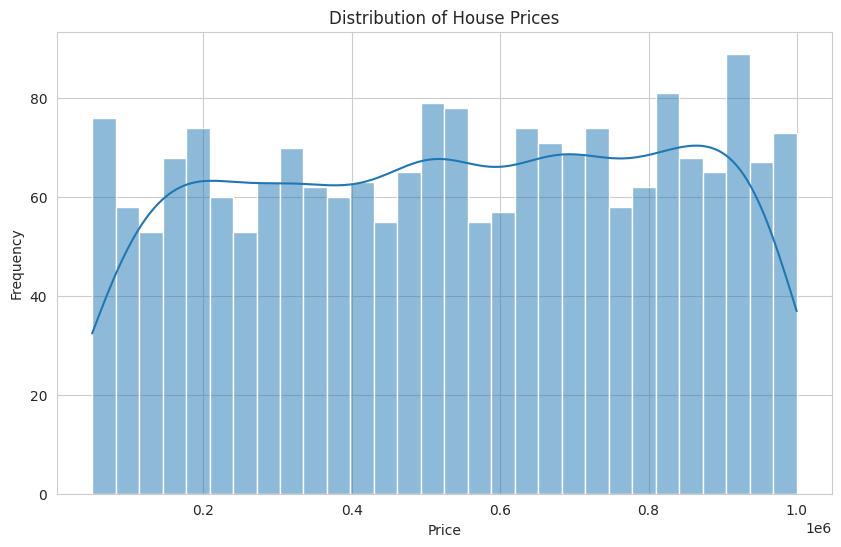

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a histogram of the target variable 'Price'
plt.figure(figsize=(10, 6))
sns.histplot(house_df['Price'], kde=True, bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Now, let's examine the correlation matrix for numerical features to understand the relationships between variables, especially with the 'Price' column.

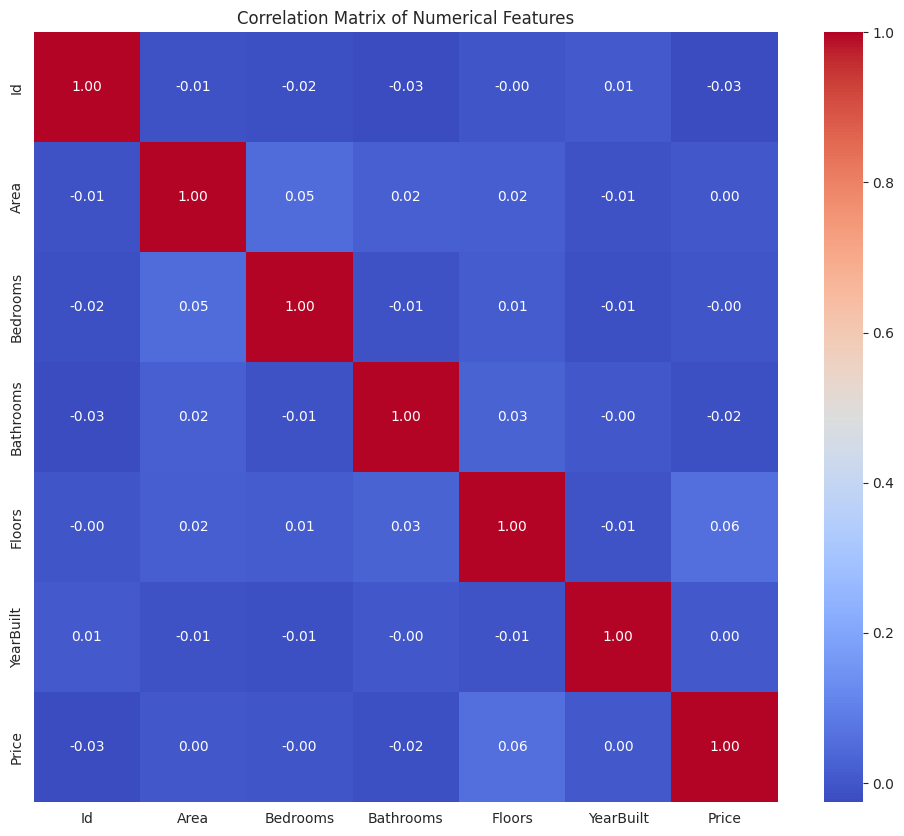

In [ ]:
# Calculate the correlation matrix for numerical features
correlation_matrix = house_df.select_dtypes(include=['int64', 'float64']).corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Before training a model, we need to convert categorical features into a numerical representation. We'll use one-hot encoding for this purpose.

In [ ]:
# Identify categorical columns for one-hot encoding
categorical_cols = house_df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
house_df_encoded = pd.get_dummies(house_df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after one-hot encoding:", house_df_encoded.shape)
display(house_df_encoded.head())

Shape of DataFrame after one-hot encoding: (2000, 14)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


With the categorical features encoded, the next step is to split the data into features (X) and the target variable (y), and then further divide it into training and testing sets. This will allow us to train our model on one part of the data and evaluate its performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = house_df_encoded.drop('Price', axis=1)
y = house_df_encoded['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1600, 13)
X_test shape: (400, 13)
y_train shape: (1600,)
y_test shape: (400,)


Now that our data is prepared, let's train a machine learning model. We'll start with a RandomForestRegressor, which is a powerful and flexible model for regression tasks. After training, we will evaluate its performance using common regression metrics.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 249685.40
Mean Squared Error (MSE): 83274181705.09
Root Mean Squared Error (RMSE): 288572.66
R-squared (R2): -0.07


Finally, let's visualize the model's predictions against the actual values to get a better sense of its performance and identify any patterns in the errors.

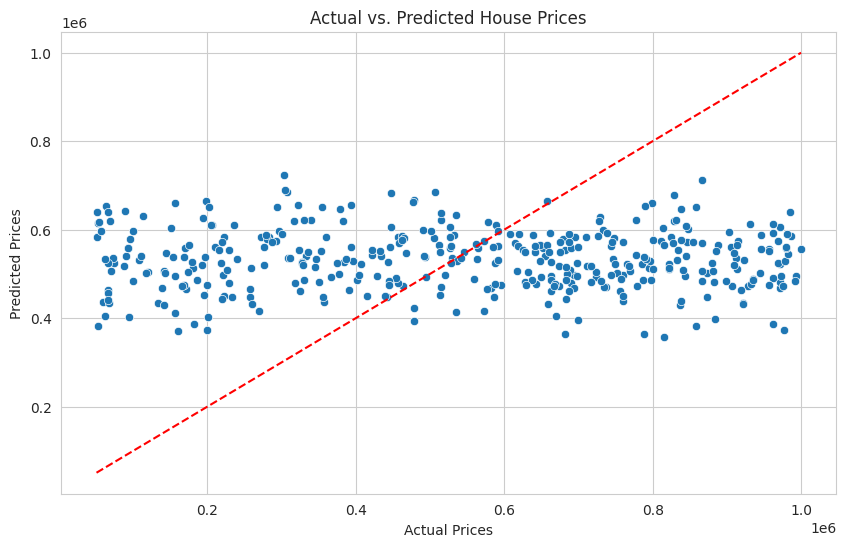

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.show()

## Project Summary

We have successfully built a machine learning model to predict house prices. Here's a brief recap of the steps taken:

1.  **Data Loading and Initial Inspection**: Loaded the `House Price Prediction Dataset.csv` and examined its basic structure and information.
2.  **Missing Value Handling**: Imputed missing numerical values with the mean and categorical values with the mode to ensure data completeness.
3.  **Exploratory Data Analysis (EDA)**:
    *   Displayed a statistical summary of numerical features.
    *   Visualized the distribution of the target variable 'Price' using a histogram.
    *   Generated a correlation heatmap to understand relationships between numerical features and the target variable.
4.  **Data Preprocessing**: Applied one-hot encoding to categorical features to convert them into a format suitable for machine learning algorithms.
5.  **Data Splitting**: Divided the dataset into training and testing sets to evaluate model performance on unseen data.
6.  **Model Training**: Trained a `RandomForestRegressor` model on the preprocessed training data.
7.  **Model Evaluation**: Evaluated the model's performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) metrics.
8.  **Prediction Visualization**: Visualized actual vs. predicted house prices to assess the model's accuracy and identify potential discrepancies.

This concludes the house price prediction project. Further steps could include hyperparameter tuning, feature engineering, or exploring other advanced models to improve prediction accuracy.